In [2]:
!wget "https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv"


--2025-05-01 04:13:42--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv [following]
--2025-05-01 04:13:43--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/clientes_segmentos%20(1).csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1032085 (1008K) [text/plain]
Saving to: ‘clientes_segmentos (1).csv’

clientes_segmento

In [12]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [14]:
plt.style.use('default')

url = '/content/clientes_segmentos (1).csv'
df = pd.read_csv(url)


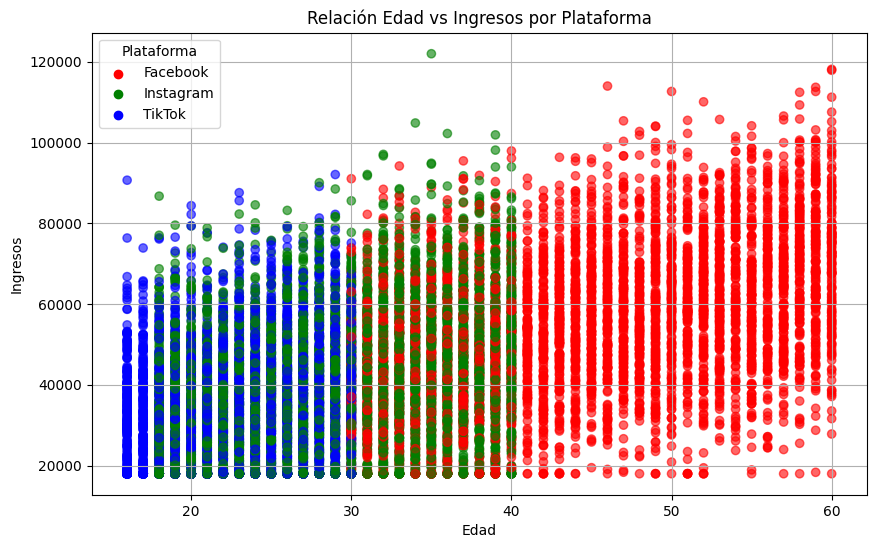

In [15]:
colors = {plataforma: color for plataforma, color in zip(df['plataforma'].unique(), ['red', 'green', 'blue'])}
df['color'] = df['plataforma'].map(colors)

plt.figure(figsize=(10, 6))
plt.scatter(df['edad'], df['ingresos'], c=df['color'], alpha=0.6)
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.title("Relación Edad vs Ingresos por Plataforma")
for plataforma, color in colors.items():
    plt.scatter([], [], c=color, label=plataforma)
plt.legend(title="Plataforma")
plt.grid(True)
plt.show()

Facebook tiene usuarios con mayores ingresos

Titok es la red social con usuarios mas jovenes

In [16]:
df['Recency'] = df['dias_desde_ultima']
df['Frequency'] = df['compras']
df['Monetary'] = df['total_gastado']


In [17]:
P2 = df[['Recency', 'Frequency', 'Monetary', 'recomendaciones']].corr()
print("\n--- P2: Correlaciones RFM + Recomendaciones ---")
print(P2)



--- P2: Correlaciones RFM + Recomendaciones ---
                  Recency  Frequency  Monetary  recomendaciones
Recency          1.000000  -0.003188 -0.003745         0.001027
Frequency       -0.003188   1.000000  0.633622         0.009415
Monetary        -0.003745   0.633622  1.000000         0.003284
recomendaciones  0.001027   0.009415  0.003284         1.000000


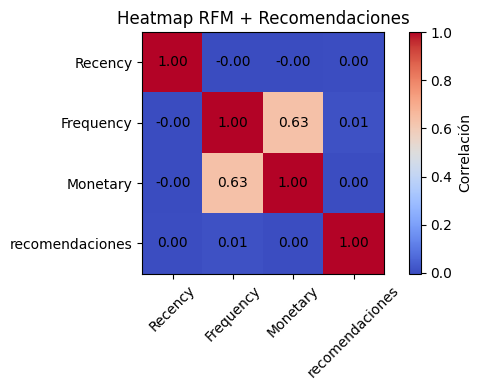

In [18]:
plt.figure(figsize=(6, 4))
plt.imshow(P2, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlación')
plt.xticks(range(len(P2.columns)), P2.columns, rotation=45)
plt.yticks(range(len(P2.index)), P2.index)
plt.title("Heatmap RFM + Recomendaciones")
for i in range(len(P2.columns)):
    for j in range(len(P2.index)):
        plt.text(i, j, f"{P2.iloc[j, i]:.2f}", ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

La mejor combinacion son FrecuEncy y Monetary
mzyor valor numerico entre variables diferentes

In [19]:
P3 = df.groupby('plataforma').agg({
    'costo_adquisicion': 'mean',
    'id_cliente': 'count'
}).rename(columns={'id_cliente': 'clientes'})

In [20]:
activos = df[df['dias_desde_ultima'] <= 90].groupby('plataforma')['id_cliente'].count()
P3['activos'] = activos
P3['%_activos'] = P3['activos'] / P3['clientes']
P3['CAC_ponderado'] = P3['costo_adquisicion'] * P3['%_activos']
print("\n--- P3: CAC ponderado por plataforma ---")
print(P3[['CAC_ponderado']])



--- P3: CAC ponderado por plataforma ---
            CAC_ponderado
plataforma               
Facebook        11.851524
Instagram        8.304206
TikTok           6.033890


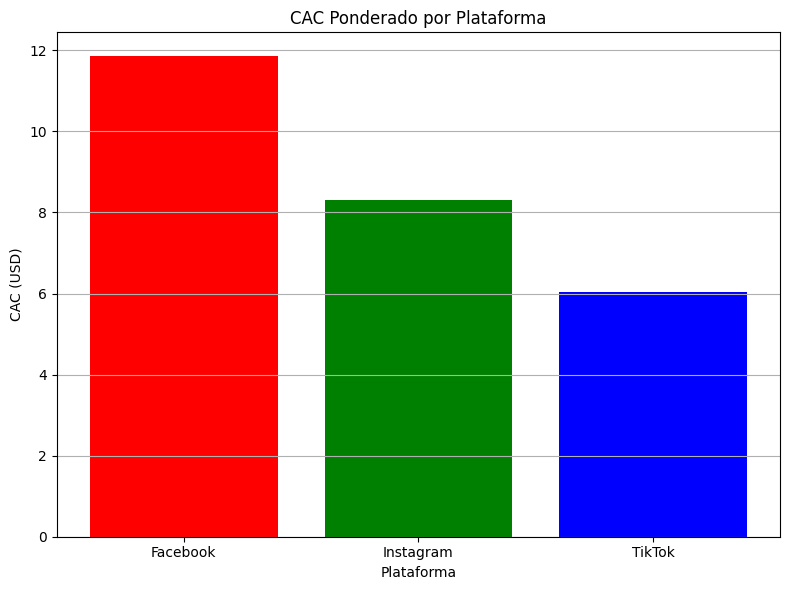

In [21]:
plt.figure(figsize=(8, 6))
bar_width = 0.6
plataformas = P3.index.tolist()
cac = P3['CAC_ponderado'].values

plt.bar(plataformas, cac, color=['red', 'green', 'blue'])
plt.title("CAC Ponderado por Plataforma")
plt.ylabel("CAC (USD)")
plt.xlabel("Plataforma")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [22]:
def retencion(dias):
    if dias <= 90:
        return 0.8
    elif dias <= 180:
        return 0.6
    else:
        return 0.3

In [24]:
if not np.issubdtype(df['fecha_primer_compra'].dtype, np.datetime64):
    df['fecha_primer_compra'] = pd.to_datetime(df['fecha_primer_compra'])

corte = datetime(2025, 4, 1)
meses_cliente = (corte - df['fecha_primer_compra']).dt.days / 30
frecuencia_mensual = df['Frequency'] / meses_cliente.replace(0, np.nan)
frecuencia_mensual = frecuencia_mensual.fillna(0)

df['retencion'] = df['dias_desde_ultima'].apply(retencion)
df['LTV'] = df['promedio_ticket'] * frecuencia_mensual * 12 * df['retencion']


In [25]:
P4_limite = df['LTV'].quantile(0.9)
P4 = df[df['LTV'] >= P4_limite]
print("\n--- P4: Clientes en el percentil 90 de LTV ---")
print(P4[['id_cliente', 'LTV']].head())



--- P4: Clientes en el percentil 90 de LTV ---
   id_cliente         LTV
17     C00017  129.961003
21     C00021  197.862595
26     C00026  191.409231
29     C00029  247.952663
39     C00039  128.822622


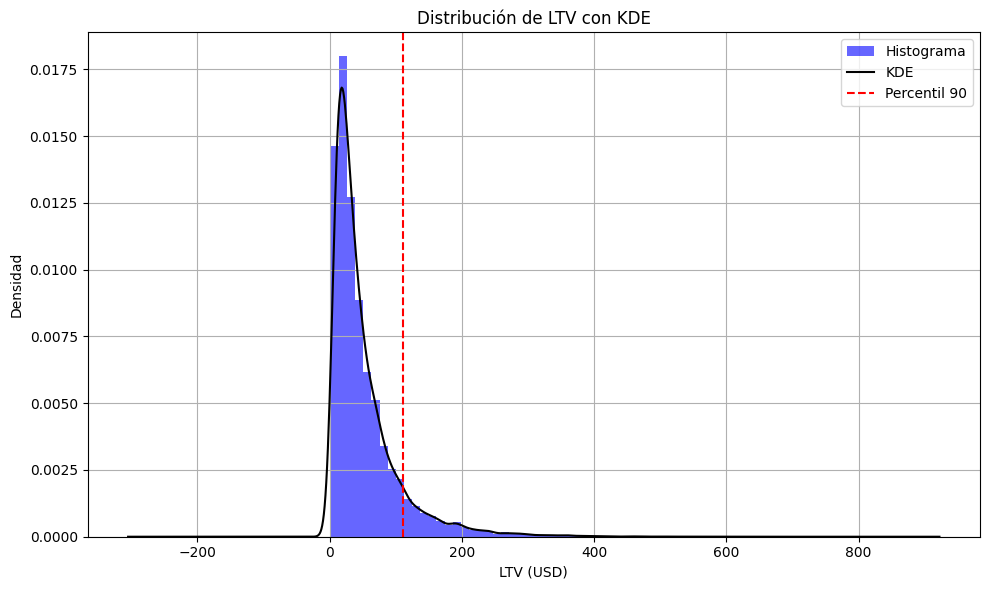

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df['LTV'], bins=50, alpha=0.6, color='blue', density=True, label='Histograma')
df['LTV'].plot(kind='kde', color='black', label='KDE')
plt.axvline(P4_limite, color='red', linestyle='--', label='Percentil 90')
plt.title("Distribución de LTV con KDE")
plt.xlabel("LTV (USD)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
df['margen'] = df['LTV'] - df['costo_adquisicion']
P5 = df.groupby('plataforma')['margen'].mean()
print("\n--- P5: Margen por plataforma ---")
print(P5)


--- P5: Margen por plataforma ---
plataforma
Facebook     59.600939
Instagram    21.450680
TikTok       12.391383
Name: margen, dtype: float64


facebook ya que  su margen es mayor y por los visto en los puntos anteriores tambien compran mas

In [29]:
from numpy.linalg import norm

X = df[['Recency', 'Frequency', 'Monetary', 'recomendaciones']].copy()
X_norm = (X - X.mean()) / X.std()


In [30]:
random.seed(42)
centroids = X_norm.sample(n=3, random_state=42).values

In [31]:
for _ in range(5):
    distances = np.array([[norm(x - c) for c in centroids] for x in X_norm.values])
    df['cluster'] = np.argmin(distances, axis=1)
    centroids = np.array([X_norm[df['cluster'] == i].mean().values for i in range(3)])


In [32]:
P7 = df[['id_cliente', 'cluster']]
print("\n--- P7: Cluster asignado por cliente ---")
print(P7.head())



--- P7: Cluster asignado por cliente ---
  id_cliente  cluster
0     C00000        2
1     C00001        0
2     C00002        1
3     C00003        0
4     C00004        0


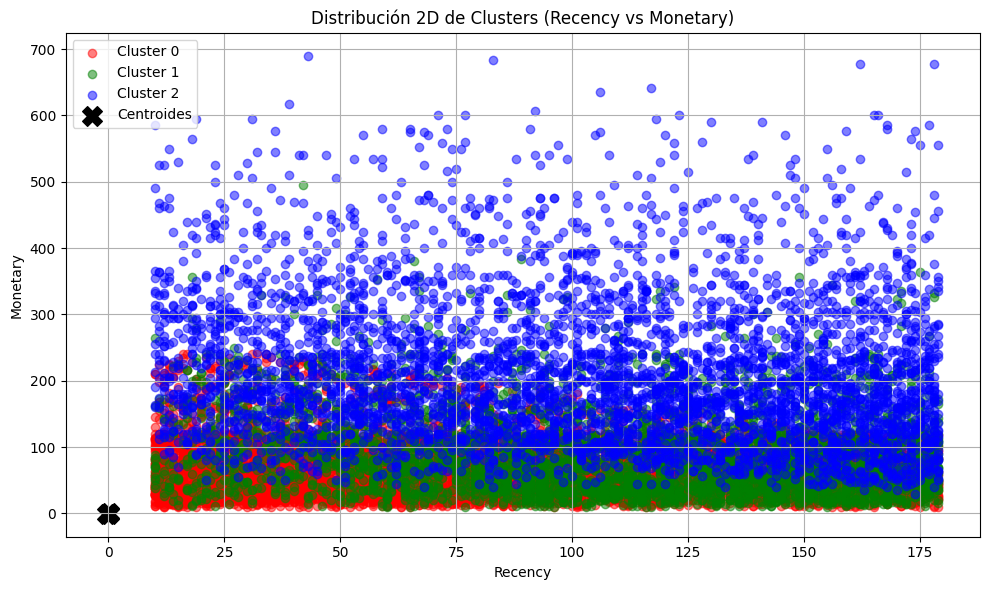

In [35]:
centros = np.array([X_norm[df['cluster'] == i][['Recency', 'Monetary']].mean().values for i in range(3)])
plt.figure(figsize=(10, 6))
for i, color in zip(range(3), ['red', 'green', 'blue']):
    subset = df[df['cluster'] == i]
    plt.scatter(subset['Recency'], subset['Monetary'], alpha=0.5, label=f"Cluster {i}", c=color)
plt.scatter(centros[:, 0], centros[:, 1], s=200, c='black', marker='X', label='Centroides')
plt.title("Distribución 2D de Clusters (Recency vs Monetary)")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cluster_nombres = {
    0: "Leales Premium <3333 ",
    1: "Referidores Frecuentes ",
    2: "Ocasionales van y vienen "}
df['cluster_nombre'] = df['cluster'].map(cluster_nombres)


In [36]:
margen_75 = df['margen'].quantile(0.75)
df['high_margin'] = (df['margen'] >= margen_75).astype(int)

In [37]:
presupuesto = 10000
P9_margen = df.groupby('cluster')['margen'].mean()
clientes_cluster = df['cluster'].value_counts()



In [38]:
c1 = P9_margen.idxmax()
roi1 = P9_margen[c1] * presupuesto / presupuesto

top2 = P9_margen.sort_values(ascending=False).head(2)
roi2 = top2.mean()

total_m = P9_margen.sum()
roi3 = sum((P9_margen / total_m) * (presupuesto / 3)) / presupuesto


In [40]:
escenarios = pd.DataFrame({
    'Escenario': ["1 - Cluster más rentable", "2 - Promedio top 2 clusters", "3 - Distribución proporcional"],
    'ROI': [roi1, roi2, roi3]
})
print("\nTabla de ROI por escenario:")
print(escenarios)



Tabla de ROI por escenario:
                       Escenario        ROI
0       1 - Cluster más rentable  73.288337
1    2 - Promedio top 2 clusters  46.997936
2  3 - Distribución proporcional   0.333333


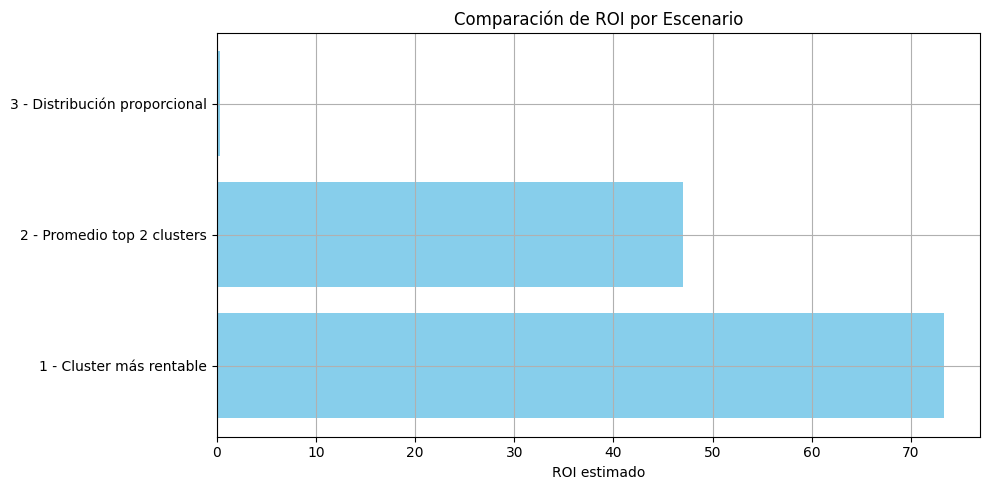

In [41]:
plt.figure(figsize=(10, 5))
plt.barh(escenarios['Escenario'], escenarios['ROI'], color='skyblue')
plt.title('Comparación de ROI por Escenario')
plt.xlabel('ROI estimado')
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
P10_top = df.sort_values('recomendaciones', ascending=False).head(int(0.1 * len(df)))
cluster_means = df.groupby('cluster')[['promedio_ticket', 'Frequency', 'retencion']].mean()
cluster_means['LTV_estimado'] = cluster_means['promedio_ticket'] * cluster_means['Frequency'] * 12 * cluster_means['retencion']


In [53]:
valores_adv = []
labels = []
for idx, row in P10_top.iterrows():
    cl = row['cluster']
    if cl in cluster_means.index:
        valor = cluster_means.loc[cl, 'LTV_estimado'] * 2
        valores_adv.append(valor)
        labels.append(f"C{row['id_cliente'][-3:]} - Cl {cl}")

total_valor_advocates = sum(valores_adv)
print("\n--- P10: Valor total de advocates ---")
print(f"Valor estimado total: ${total_valor_advocates:,.2f}")


--- P10: Valor total de advocates ---
Valor estimado total: $2,535,245.23


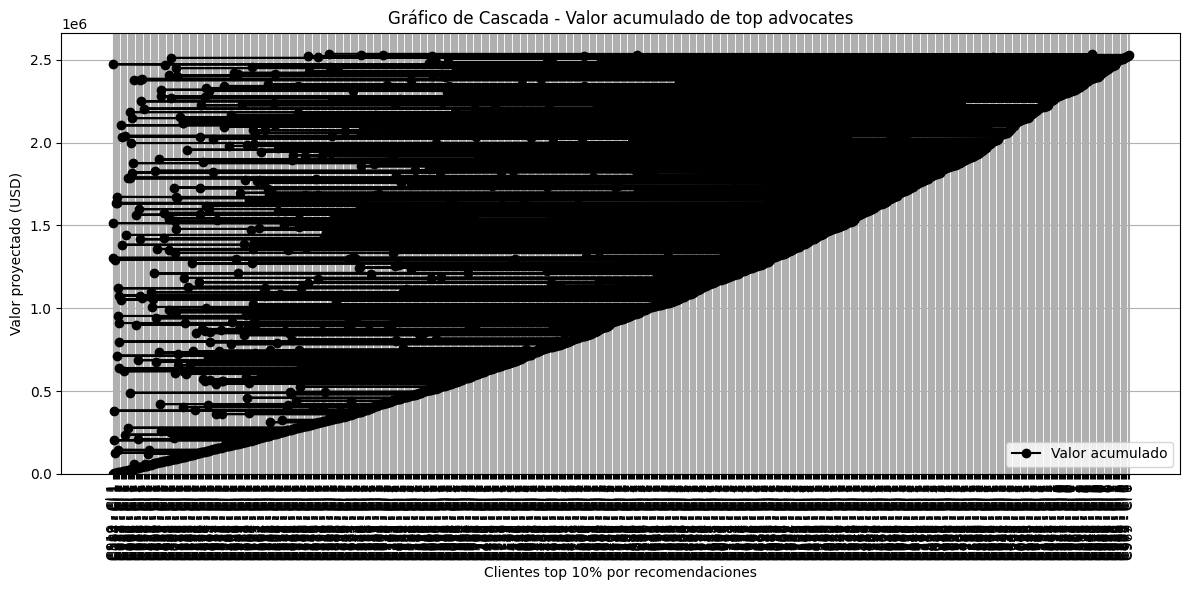

In [54]:
acumulado = np.cumsum(valores_adv)
plt.figure(figsize=(12, 6))
plt.bar(labels, valores_adv, color='lightblue')
plt.plot(labels, acumulado, marker='o', color='black', label='Valor acumulado')
plt.xticks(rotation=90)
plt.title("Gráfico de Cascada - Valor acumulado de top advocates")
plt.xlabel("Clientes top 10% por recomendaciones")
plt.ylabel("Valor proyectado (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


el El Escenario 1 es óptimo si el objetivo principal es maximizar la rentabilidad financiera inmediata, especialmente en un entorno de recursos limitados, ya que tiene un ROI msyor : de 59.60 por cada 100 invertidos

1 no todos los clientes usan todas las plataformas

2 existe una falta de otro tipo de datos  como lo podrian ser el tiempo en la app

3 debido a que algunos clientes son recientes puede hacer parecer que su life time value es menor debido al tiempo que llevan en nuestras bases de datos

---

